# Figure 3: Incoherent Feedforward Loop (IFFL) and Robust Perfect Adaptation

**Panel A** — Equations of the IFFL model:

$$\frac{dx}{dt} = \alpha\,u - \delta\,x$$
$$\frac{dy}{dt} = \beta\,u - \gamma\,x\,y$$

In [78]:
"""Shared parameters, ODE models, simulation functions, and plotting helpers for Figure 3."""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp
import sys
sys.path.insert(0, '../src')
from rpa_control.style import set_style

set_style()
plt.rcParams['text.usetex'] = False

# ======================================================================
# Plotting helpers
# ======================================================================

def text_panel(ax, lines, fontsize=11):
    ax.axis('off')
    ax.text(0.05, 0.95, '\n'.join(lines), transform=ax.transAxes,
            fontsize=fontsize, verticalalignment='top', family='serif', linespacing=1.6)

def clean_ax(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# ======================================================================
# Shared parameters
# ======================================================================

PARAMS = dict(alpha=1.0, delta=1.0, beta=1.0, gamma=1.0)

def steady_state(u, p=PARAMS):
    x_ss = p['alpha'] * u / p['delta']
    y_ss = p['beta'] * p['delta'] / (p['gamma'] * p['alpha'])
    return x_ss, y_ss

# --- Panel B: single u switch ---
PANEL_B = dict(
    u_base=1.0,
    u_pert=2.0,
    t_switch=1.0,
    t_end=11.0,
)

# --- Panel C: gradual ramp u=1→0.5, then abrupt jump to u=2 ---
PANEL_C = dict(
    u_start=1.0,
    u_ramp_end=0.5,
    u_abrupt=2.0,
    t_flat=0.0,      # hold at u=1 for 1 s
    t_ramp=30.0,      # ramp duration
    t_end=40.0,      # 10 s after abrupt jump
)
PANEL_C['t_abrupt'] = PANEL_C['t_flat'] + PANEL_C['t_ramp']

# ======================================================================
# ODE right-hand side
# ======================================================================

def iffl_rhs(y_state, u, p=PARAMS):
    x, y = y_state
    dx_dt = p['alpha'] * u - p['delta'] * x
    dy_dt = p['beta'] * u - p['gamma'] * x * y
    return np.array([dx_dt, dy_dt])

# ======================================================================
# Simulation runners
# ======================================================================

def run_panel_B():
    p = PANEL_B
    x_ss, y_ss = steady_state(p['u_base'])
    x0_ss = [x_ss, y_ss]

    t1 = np.linspace(0, p['t_switch'], 250)
    sol1 = solve_ivp(
        lambda t_, y: iffl_rhs(y, p['u_base']).tolist(),
        [0, p['t_switch']], x0_ss, dense_output=True, max_step=0.05)
    y_switch = sol1.sol(p['t_switch'])

    t2 = np.linspace(p['t_switch'], p['t_end'], 500)
    sol2 = solve_ivp(
        lambda t_, y: iffl_rhs(y, p['u_pert']).tolist(),
        [p['t_switch'], p['t_end']], y_switch, dense_output=True, max_step=0.05)

    t_full = np.concatenate([t1, t2[1:]])
    x_full = np.concatenate([sol1.sol(t1)[0], sol2.sol(t2[1:])[0]])
    y_full = np.concatenate([sol1.sol(t1)[1], sol2.sol(t2[1:])[1]])
    return dict(t=t_full, x=x_full, y=y_full, t_switch=p['t_switch'],
                y_ss=y_ss,
                label_base=rf'$u={p["u_base"]}$',
                label_pert=rf'$u={p["u_pert"]}$')

def run_panel_C():
    p = PANEL_C
    x_ss, y_ss = steady_state(p['u_start'])

    # Phase 1: flat at u_start
    t1 = np.linspace(0, p['t_flat'], 100)
    sol1 = solve_ivp(
        lambda t_, y: iffl_rhs(y, p['u_start']).tolist(),
        [0, p['t_flat']], [x_ss, y_ss], dense_output=True, max_step=0.05)

    # Phase 2: linear ramp u from u_start → u_ramp_end
    def u_ramp(t_):
        frac = (t_ - p['t_flat']) / p['t_ramp']
        return p['u_start'] + (p['u_ramp_end'] - p['u_start']) * frac

    t2 = np.linspace(p['t_flat'], p['t_abrupt'], 400)
    sol2 = solve_ivp(
        lambda t_, y: iffl_rhs(y, u_ramp(t_)).tolist(),
        [p['t_flat'], p['t_abrupt']], sol1.sol(p['t_flat']),
        dense_output=True, max_step=0.02)

    # Phase 3: abrupt jump to u_abrupt
    t3 = np.linspace(p['t_abrupt'], p['t_end'], 500)
    sol3 = solve_ivp(
        lambda t_, y: iffl_rhs(y, p['u_abrupt']).tolist(),
        [p['t_abrupt'], p['t_end']], sol2.sol(p['t_abrupt']),
        dense_output=True, max_step=0.05)

    t_full = np.concatenate([t1, t2[1:], t3[1:]])
    y_full = np.concatenate([sol1.sol(t1)[1], sol2.sol(t2[1:])[1], sol3.sol(t3[1:])[1]])
    u_full = np.concatenate([
        np.full_like(t1, p['u_start']),
        np.array([u_ramp(t_) for t_ in t2[1:]]),
        np.full_like(t3[1:], p['u_abrupt']),
    ])
    return dict(t=t_full, y=y_full, u=u_full,
                y_ss=y_ss,
                t_flat=p['t_flat'], t_abrupt=p['t_abrupt'])

# ======================================================================
# Run all simulations
# ======================================================================
data_B = run_panel_B()
data_C = run_panel_C()

print("All simulations complete.")
x_ss_base, y_ss = steady_state(PANEL_B['u_base'])
x_ss_pert, _    = steady_state(PANEL_B['u_pert'])
print(f"Panel B — base ss: x={x_ss_base:.3f}, y={y_ss:.3f}")
print(f"Panel B — pert ss: x={x_ss_pert:.3f}, y={y_ss:.3f}  (y unchanged)")

All simulations complete.
Panel B — base ss: x=1.000, y=1.000
Panel B — pert ss: x=2.000, y=1.000  (y unchanged)


**Panel A** — IFFL model equations and steady-state analysis:

$$\frac{dx}{dt} = \alpha\,u - \delta\,x \qquad \frac{dy}{dt} = \beta\,u - \gamma\,x\,y$$

Setting both derivatives to zero:

$$x_{ss} = \frac{\alpha\,u}{\delta}, \qquad y_{ss} = \frac{\beta\,\delta}{\gamma\,\alpha}$$

The steady state $y_{ss}$ is **independent of $u$** — robust perfect adaptation.

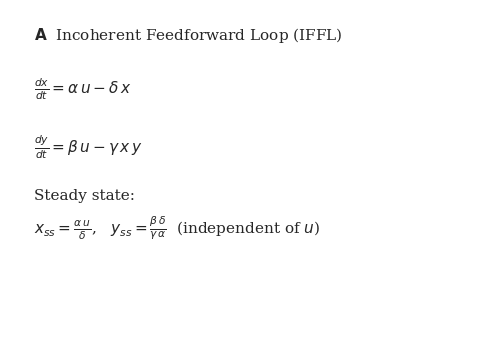

In [79]:
# Panel A: standalone equations figure
fig, ax = plt.subplots(figsize=(5, 3.5))
text_panel(ax, [
    r'$\mathbf{A}$  Incoherent Feedforward Loop (IFFL)',
    '',
    r'$\frac{dx}{dt} = \alpha\,u - \delta\,x$',
    '',
    r'$\frac{dy}{dt} = \beta\,u - \gamma\,x\,y$',
    '',
    r'Steady state:',
    r'$x_{ss} = \frac{\alpha\,u}{\delta}$,   '
    r'$y_{ss} = \frac{\beta\,\delta}{\gamma\,\alpha}$  (independent of $u$)',
], fontsize=11)
plt.tight_layout()
fig.savefig('figure3_panelA.pdf', bbox_inches='tight')
plt.show()

**Panel B** — Starting at steady state, changing $u$ does not affect $y_{ss}$:

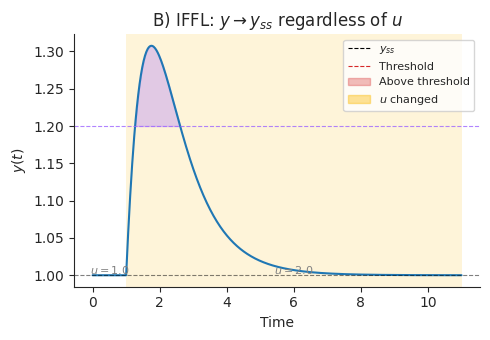

In [80]:
# Panel B: standalone plot
THRESHOLD = 1.2

fig, ax = plt.subplots(figsize=(5, 3.5))

ax.axvspan(data_B['t_switch'], data_B['t'].max(), color='#fcba03', alpha=0.15, lw=0)
ax.plot(data_B['t'], data_B['y'], lw=1.5, color='C0')
ax.fill_between(data_B['t'], THRESHOLD, data_B['y'],
                where=(data_B['y'] > THRESHOLD), color='#9e66ff', alpha=0.3, interpolate=True)
ax.axhline(data_B['y_ss'], color='black', ls='--', lw=0.8, alpha=0.5)
ax.axhline(THRESHOLD, color='#9e66ff', ls='--', lw=0.8, alpha=0.8)
ax.set_ylabel('$y(t)$')
ax.set_xlabel('Time')
ax.set_title(r'B) IFFL: $y \to y_{ss}$ regardless of $u$')

ax.text(0.5, 0.05, data_B['label_base'], ha='center', fontsize=8, color='gray',
        transform=ax.get_xaxis_transform())
ax.text(6.0, 0.05, data_B['label_pert'], ha='center', fontsize=8, color='gray',
        transform=ax.get_xaxis_transform())

ax.legend(handles=[
    plt.Line2D([0],[0], color='black', ls='--', lw=0.8, label=r'$y_{ss}$'),
    plt.Line2D([0],[0], color='C3',   ls='--', lw=0.8, label='Threshold'),
    mpatches.Patch(color='C3', alpha=0.3, label='Above threshold'),
    mpatches.Patch(color='#fcba03', alpha=0.4, label='$u$ changed'),
], fontsize=8, loc='upper right')
clean_ax(ax)
plt.tight_layout()
fig.savefig('figure3_panelB.pdf', bbox_inches='tight')
plt.show()

**Panel C** — Gradual ramp $u: 1 \to 0.5$, then abrupt jump to $u=2$:

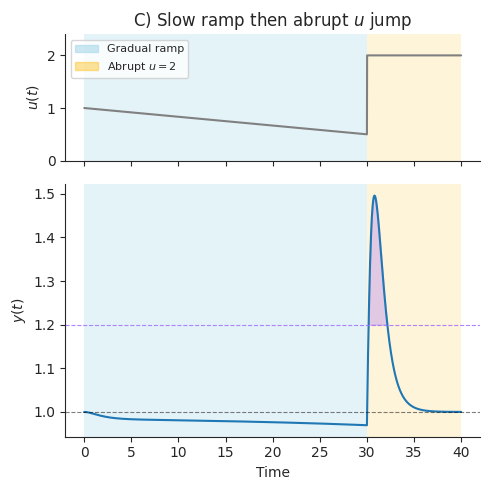

In [81]:
# Panel C: standalone plot — two subplots: u(t) on top, y(t) below
fig, (ax_u, ax_y) = plt.subplots(2, 1, figsize=(5, 5), sharex=True,
                                  gridspec_kw={'height_ratios': [1, 2]})

# Shading
ax_u.axvspan(data_C['t_flat'],   data_C['t_abrupt'], color='#a8d8ea', alpha=0.3, lw=0)
ax_u.axvspan(data_C['t_abrupt'], data_C['t'].max(),  color='#fcba03', alpha=0.15, lw=0)
ax_y.axvspan(data_C['t_flat'],   data_C['t_abrupt'], color='#a8d8ea', alpha=0.3, lw=0)
ax_y.axvspan(data_C['t_abrupt'], data_C['t'].max(),  color='#fcba03', alpha=0.15, lw=0)

# u(t)
ax_u.plot(data_C['t'], data_C['u'], lw=1.5, color='gray')
ax_u.set_ylabel('$u(t)$')
ax_u.set_ylim(0, 2.4)
clean_ax(ax_u)

# y(t)
THRESHOLD = 1.2
ax_y.plot(data_C['t'], data_C['y'], lw=1.5, color='C0')
ax_y.fill_between(data_C['t'], THRESHOLD, data_C['y'],
                  where=(data_C['y'] > THRESHOLD), color="#9e66ff", alpha=0.3, interpolate=True)
ax_y.axhline(data_C['y_ss'], color='black', ls='--', lw=0.8, alpha=0.5)
ax_y.axhline(THRESHOLD, color='#9e66ff', ls='--', lw=0.8, alpha=0.8)
ax_y.set_ylabel('$y(t)$')
ax_y.set_xlabel('Time')
clean_ax(ax_y)

ax_u.set_title(r'C) Slow ramp then abrupt $u$ jump')
ax_u.legend(handles=[
    mpatches.Patch(color='#a8d8ea', alpha=0.6, label='Gradual ramp'),
    mpatches.Patch(color='#fcba03', alpha=0.4, label='Abrupt $u=2$'),
], fontsize=8, loc='upper left')

plt.tight_layout()
fig.savefig('figure3_panelC.pdf', bbox_inches='tight')
plt.show()

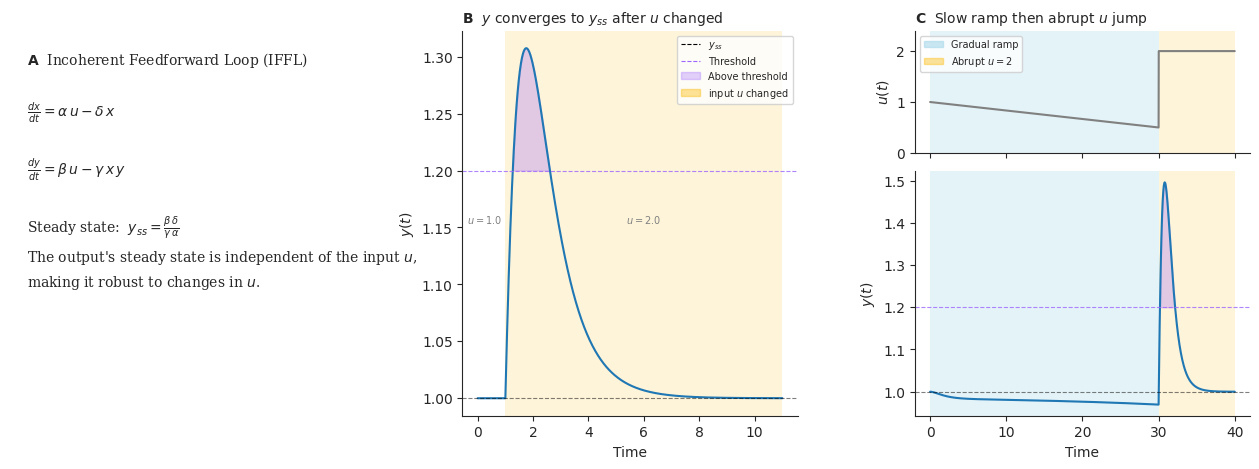

Saved figure3_composite.pdf


In [82]:
# ======================================================================
# COMPOSITE FIGURE  —  A | B | C
# ======================================================================
THRESHOLD = 1.2

fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# --- Panel A: equations ---
ax_A = fig.add_subplot(gs[0, 0])
text_panel(ax_A, [
    r'$\mathbf{A}$  Incoherent Feedforward Loop (IFFL)',
    '',
    r'$\frac{dx}{dt} = \alpha\,u - \delta\,x$',
    '',
    r'$\frac{dy}{dt} = \beta\,u - \gamma\,x\,y$',
    '',
    r'Steady state:  $y_{ss} = \frac{\beta\,\delta}{\gamma\,\alpha}$',
    r"The output's steady state is independent of the input $u$,",
    r"making it robust to changes in $u$.",
], fontsize=10)

# --- Panel B: abrupt u switch ---
ax_B = fig.add_subplot(gs[0, 1])
ax_B.axvspan(data_B['t_switch'], data_B['t'].max(), color='#fcba03', alpha=0.15, lw=0)
ax_B.plot(data_B['t'], data_B['y'], lw=1.5, color='C0')
ax_B.fill_between(data_B['t'], THRESHOLD, data_B['y'],
                  where=(data_B['y'] > THRESHOLD), color='#9e66ff', alpha=0.3, interpolate=True)
ax_B.axhline(data_B['y_ss'], color='black', ls='--', lw=0.8, alpha=0.5)
ax_B.axhline(THRESHOLD, color='#9e66ff', ls='--', lw=0.8, alpha=0.8)
ax_B.set_ylabel('$y(t)$'); ax_B.set_xlabel('Time')
ax_B.set_title(r'$\mathbf{B}$  $y$ converges to $y_{ss}$ after $u$ changed', fontsize=10, loc='left')
ax_B.legend(handles=[
    plt.Line2D([0],[0], color='black', ls='--', lw=0.8, label=r'$y_{ss}$'),
    plt.Line2D([0],[0], color='#9e66ff',   ls='--', lw=0.8, label='Threshold'),
    mpatches.Patch(color='#9e66ff', alpha=0.3, label='Above threshold'),
    mpatches.Patch(color='#fcba03', alpha=0.4, label='input $u$ changed'),
], fontsize=7, loc='upper right')
ax_B.text(0.25, 0.5, data_B['label_base'], ha='center', fontsize=7, color='gray',
          transform=ax_B.get_xaxis_transform())
ax_B.text(6.0,  0.5, data_B['label_pert'], ha='center', fontsize=7, color='gray',
          transform=ax_B.get_xaxis_transform())
clean_ax(ax_B)

# --- Panel C: ramp + abrupt jump — u(t) on top, y(t) below ---
gs_C = gs[0, 2].subgridspec(2, 1, height_ratios=[1, 2], hspace=0.1)
ax_Cu = fig.add_subplot(gs_C[0])
ax_Cy = fig.add_subplot(gs_C[1], sharex=ax_Cu)

for ax in [ax_Cu, ax_Cy]:
    ax.axvspan(data_C['t_flat'],   data_C['t_abrupt'], color='#a8d8ea', alpha=0.3, lw=0)
    ax.axvspan(data_C['t_abrupt'], data_C['t'].max(),  color='#fcba03', alpha=0.15, lw=0)

ax_Cu.plot(data_C['t'], data_C['u'], lw=1.5, color='gray')
ax_Cu.set_ylabel('$u(t)$'); ax_Cu.set_ylim(0, 2.4)
ax_Cu.set_title(r'$\mathbf{C}$  Slow ramp then abrupt $u$ jump', fontsize=10, loc='left')
ax_Cu.legend(handles=[
    mpatches.Patch(color='#a8d8ea', alpha=0.6, label='Gradual ramp'),
    mpatches.Patch(color='#fcba03', alpha=0.4, label='Abrupt $u=2$'),
], fontsize=7, loc='upper left')
clean_ax(ax_Cu)
plt.setp(ax_Cu.get_xticklabels(), visible=False)

ax_Cy.plot(data_C['t'], data_C['y'], lw=1.5, color='C0')
ax_Cy.fill_between(data_C['t'], THRESHOLD, data_C['y'],
                   where=(data_C['y'] > THRESHOLD), color='#9e66ff', alpha=0.3, interpolate=True)
ax_Cy.axhline(data_C['y_ss'], color='black', ls='--', lw=0.8, alpha=0.5)
ax_Cy.axhline(THRESHOLD, color='#9e66ff', ls='--', lw=0.8, alpha=0.8)
ax_Cy.set_ylabel('$y(t)$'); ax_Cy.set_xlabel('Time')
clean_ax(ax_Cy)

fig.savefig('figure3_composite.pdf', bbox_inches='tight')
plt.show()
print("Saved figure3_composite.pdf")